### Test 1: Making a RA vs dec plot. 
##### Converted Ecliptic longitude $\lambda$ = 0-360$\degree$ while Ecliptic latitude $\beta$ = is 0$\degree$
##### Used Astropy's GeocentricTrueEcliptic with equinox set to 2025-09-23
##### Transformed the points to ICRS for the plot

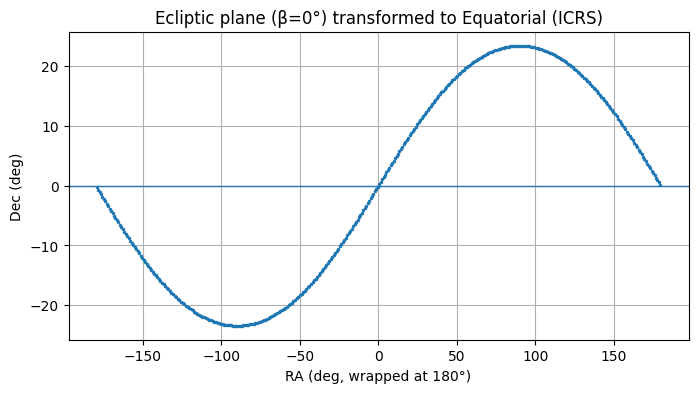

At ecliptic (λ,β)=(90°,0°):
  RA = 89.60107298148182 deg
  Dec= 23.435428483453197 deg


In [17]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GeocentricTrueEcliptic, ICRS

# Build ecliptic coordinates: lambda 0 -> 360, beta = 0 
lam = np.linspace(0, 360, 361) * u.deg
beta = np.zeros_like(lam.value) * u.deg

# Picking fall equinox
equinox = Time("2025-09-23", scale="utc")

ecl = SkyCoord(
    lon=lam,
    lat=beta,
    frame=GeocentricTrueEcliptic(equinox=equinox),
)

# Convert to equatorial (ICRS)
eq = ecl.transform_to(ICRS())

ra = eq.ra.wrap_at(180 * u.deg).deg   # wrap for nicer plotting (-180 - 180)
dec = eq.dec.deg

# Plot RA vs Dec 
plt.figure(figsize=(8, 4))
plt.plot(ra, dec, ".", ms=3)
plt.axhline(0, lw=1)
plt.xlabel("RA (deg, wrapped at 180°)")
plt.ylabel("Dec (deg)")
plt.title("Ecliptic plane (β=0°) transformed to Equatorial (ICRS)")
plt.grid(True)
plt.show()

# Check at lambda = 90 
idx_90 = np.argmin(np.abs(lam.to_value(u.deg) - 90.0))
print("At ecliptic (λ,β)=(90°,0°):")
print("  RA =", eq.ra[idx_90].deg, "deg")
print("  Dec=", eq.dec[idx_90].deg, "deg")


### Test 2: Inverse Transformation from Equatorial --> Ecliptic
##### Taking the same RA/dec from Test 1 and going back to ecliptic coords with GeocentricTrueEcliptic

In [19]:
equinox = Time("2025-09-23", scale="utc")

# Take RA/Dec and go back to ecliptic
eq = SkyCoord(
    ra=ra * u.deg,
    dec=dec * u.deg,
    frame="icrs",
)

ecl_back = eq.transform_to(
    GeocentricTrueEcliptic(equinox=equinox)
)

lam_back = ecl_back.lon.deg
beta_back = ecl_back.lat.deg

print("max |beta| (deg):", np.max(np.abs(beta_back))) # v close to 0
print("max |Δlambda| (deg):", np.max(np.abs((lam_back - lam.to_value(u.deg)) % 360)))

max |beta| (deg): 3.498610149609869e-14
max |Δlambda| (deg): 359.99999999999994


#### Test 3: Sun's motion over a year
##### Calc. Sun's apparent position using get_sun() for 365 days starting from 2025-09-23
##### Converted the Sun's position to RA/dec (ICRS) 
##### Overplotted the Sun's position onto the ecliptic curve from Test 1

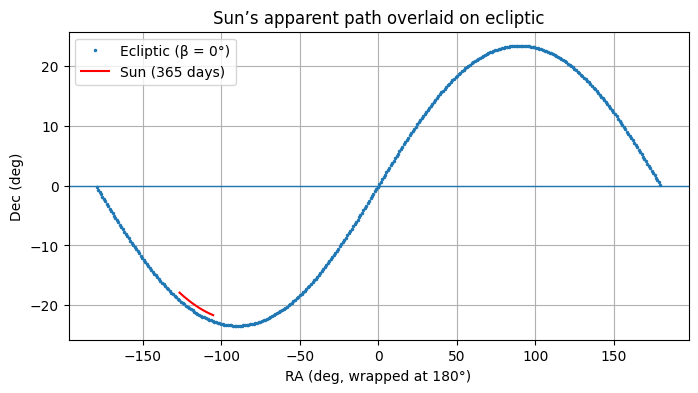

In [20]:
from astropy.coordinates import get_sun

# 365 days starting Sep 23, 2025 
t0 = Time("2025-09-23", scale="utc")
times = t0 + np.arange(365) * u.day

# Sun position in RA/Dec 
sun = get_sun(times).transform_to(ICRS())

sun_ra = sun.ra.wrap_at(180 * u.deg).deg
#sun_ra = sun.ra.deg
sun_dec = sun.dec.deg

# Plot: ecliptic curve + Sun track 
plt.figure(figsize=(8, 4))

# ecliptic line from test 1
plt.plot(ra, dec, ".", ms=3, label="Ecliptic (β = 0°)")

# Sun 
plt.plot(sun_ra, sun_dec, "r-", lw=1.5, label="Sun (365 days)")

plt.axhline(0, lw=1)
plt.xlabel("RA (deg, wrapped at 180°)")
plt.ylabel("Dec (deg)")
plt.legend()
plt.grid(True)
plt.title("Sun’s apparent path overlaid on ecliptic")
plt.show()


#### Test 4: Sun and anti-Sun position on Fall equinox (or well more like Sept. 23rd)
##### Calc. Sun's position on 23rd Sept.
##### Convert the Sun to ecliptic coords.
##### Defined anti-Sun position by adding 180$\degree$ in ecliptic longitude
##### Transformed both back to RA/dec to plot on ecliptic curve

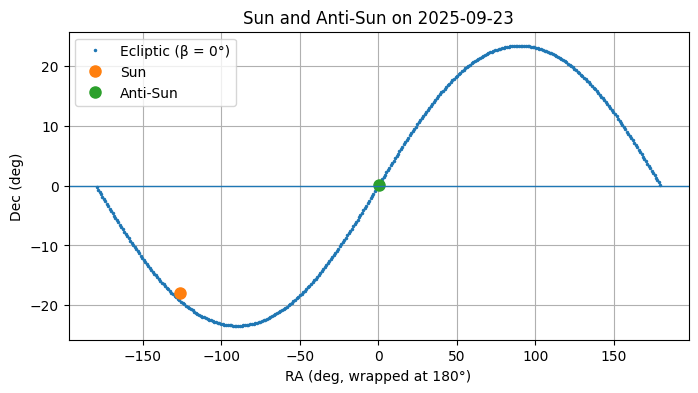

Sun  (λ,β) = 180.72108041599003 -7.755749236161028e-05
Anti (λ,β) = 0.721080415990059 7.755749236161028e-05


In [23]:
# Sept. 23rd Equinox
t = Time("2025-09-23 12:00:00", scale="utc")
ecl_frame = GeocentricTrueEcliptic(equinox=t)

# Sun converted to ecliptic lon/lat
sun_icrs = get_sun(t).transform_to(ICRS())
sun_ecl  = sun_icrs.transform_to(ecl_frame)

# Anti-sun in ecliptic: lon+180, lat doesn't count since 0 anyway
anti_ecl = SkyCoord(lon=sun_ecl.lon + 180*u.deg, lat=-sun_ecl.lat, frame=ecl_frame)

# Convert both back to ICRS for plotting on the RA/Dec ecliptic curve
sun_plot  = sun_ecl.transform_to(ICRS())
anti_plot = anti_ecl.transform_to(ICRS())

sun_ra  = sun_plot.ra.wrap_at(180*u.deg).deg
sun_dec = sun_plot.dec.deg
anti_ra  = anti_plot.ra.wrap_at(180*u.deg).deg
anti_dec = anti_plot.dec.deg

plt.figure(figsize=(8,4))
plt.plot(ra, dec, ".", ms=3, label="Ecliptic (β = 0°)")
plt.plot(sun_ra,  sun_dec,  "o", ms=8, label="Sun")
plt.plot(anti_ra, anti_dec, "o", ms=8, label="Anti-Sun")
plt.axhline(0, lw=1)
plt.xlabel("RA (deg, wrapped at 180°)")
plt.ylabel("Dec (deg)")
plt.legend()
plt.grid(True)
plt.title("Sun and Anti-Sun on 2025-09-23")
plt.show()

# Checking the ecliptic coords:
print("Sun  (λ,β) =", sun_ecl.lon.deg, sun_ecl.lat.deg)
print("Anti (λ,β) =", (sun_ecl.lon + 180*u.deg).wrap_at(360*u.deg).deg, (-sun_ecl.lat).deg)
